In [3]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
BASE_DIR = Path().cwd().parent

In [5]:
df1 = pd.read_parquet( BASE_DIR / "data" / "raw" / "swiss_load_full.parquet")

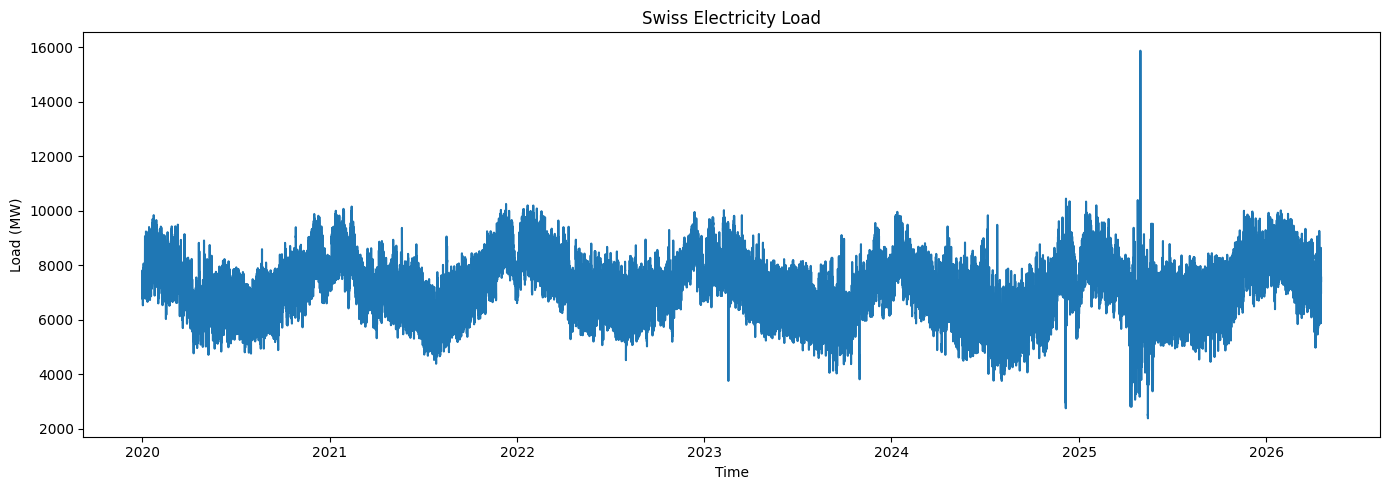

In [6]:
df1["timestamp_utc"] = pd.to_datetime(df1["timestamp_utc"])

plt.figure(figsize=(14, 5))
plt.plot(df1["timestamp_utc"], df1["load_mw"])
plt.title("Swiss Electricity Load")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()

In [7]:
df1

,timestamp_utc,load_mw
0,2020-01-01 00:00:00+00:00,7012.490000
1,2020-01-01 01:00:00+00:00,7134.250000
2,2020-01-01 02:00:00+00:00,6972.690000
3,2020-01-01 03:00:00+00:00,7580.840000
4,2020-01-01 04:00:00+00:00,7179.810000
...,...,...
55153,2026-04-17 13:00:00+00:00,7828.799804
55154,2026-04-17 14:00:00+00:00,7744.577636
55155,2026-04-17 15:00:00+00:00,7372.714843
55156,2026-04-17 16:00:00+00:00,7574.365722


In [8]:
df = pd.read_parquet('../data/processed/swiss_weather_historical.parquet')
df

,timestamp_utc,city,location_id,latitude,longitude,elevation,retrieved_at_utc,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation_probability,precipitation,rain,snowfall,snow_depth,cloud_cover,wind_speed_10m,surface_pressure,is_day,sunshine_duration
0,2019-12-31 22:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-3.750,-7.444829,97.411911,NaN,0.0,0.0,0.00,0.00,0.0,6.952754,982.462646,0.0,0.0
1,2019-12-31 23:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-3.500,-7.007089,98.885750,NaN,0.0,0.0,0.00,0.00,0.0,6.034700,982.604553,0.0,0.0
2,2020-01-01 00:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-2.350,-5.092851,99.263000,NaN,0.0,0.0,0.00,0.00,100.0,1.835647,983.673706,0.0,0.0
3,2020-01-01 01:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-3.300,-6.578874,98.152122,NaN,0.0,0.0,0.00,0.00,100.0,4.553679,982.926819,0.0,0.0
4,2020-01-01 02:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-3.550,-6.844539,98.148285,NaN,0.0,0.0,0.00,0.00,100.0,4.452954,983.165039,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547435,2026-03-30 17:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-2.834,-6.437446,95.632675,NaN,1.0,0.0,0.70,1.45,100.0,6.877789,849.789673,1.0,0.0
547436,2026-03-30 18:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-3.984,-7.213524,96.677071,NaN,1.3,0.0,0.91,1.46,100.0,3.494968,849.719299,0.0,0.0
547437,2026-03-30 19:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-3.784,-7.353294,95.958748,NaN,1.8,0.0,1.26,1.48,100.0,5.904439,850.332458,0.0,0.0
547438,2026-03-30 20:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-4.134,-7.961225,87.607178,NaN,1.6,0.0,1.12,1.48,100.0,6.502461,850.631958,0.0,0.0


In [11]:
df = df.merge(df1,how='inner')
df

,timestamp_utc,city,location_id,latitude,longitude,elevation,retrieved_at_utc,temperature_2m,apparent_temperature,relative_humidity_2m,...,precipitation,rain,snowfall,snow_depth,cloud_cover,wind_speed_10m,surface_pressure,is_day,sunshine_duration,load_mw
0,2020-01-01 00:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-2.350,-5.092851,99.263000,...,0.0,0.0,0.00,0.00,100.0,1.835647,983.673706,0.0,0.0,7012.490000
1,2020-01-01 01:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-3.300,-6.578874,98.152122,...,0.0,0.0,0.00,0.00,100.0,4.553679,982.926819,0.0,0.0,7134.250000
2,2020-01-01 02:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-3.550,-6.844539,98.148285,...,0.0,0.0,0.00,0.00,100.0,4.452954,983.165039,0.0,0.0,6972.690000
3,2020-01-01 03:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-4.000,-7.152910,97.773346,...,0.0,0.0,0.00,0.00,100.0,3.075841,982.890869,0.0,0.0,7580.840000
4,2020-01-01 04:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-3.350,-6.323088,98.151344,...,0.0,0.0,0.00,0.00,100.0,2.414953,982.727539,0.0,0.0,7179.810000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547305,2026-03-30 17:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-2.834,-6.437446,95.632675,...,1.0,0.0,0.70,1.45,100.0,6.877789,849.789673,1.0,0.0,8735.749023
547306,2026-03-30 18:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-3.984,-7.213524,96.677071,...,1.3,0.0,0.91,1.46,100.0,3.494968,849.719299,0.0,0.0,8098.288085
547307,2026-03-30 19:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-3.784,-7.353294,95.958748,...,1.8,0.0,1.26,1.48,100.0,5.904439,850.332458,0.0,0.0,7548.334960
547308,2026-03-30 20:00:00+00:00,Central_CH,9,46.854130,8.300971,1474.0,2026-04-17 19:06:12.106966+00:00,-4.134,-7.961225,87.607178,...,1.6,0.0,1.12,1.48,100.0,6.502461,850.631958,0.0,0.0,7561.660644


In [31]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

df["hour"] = df["timestamp_utc"].dt.hour
df["dayofweek"] = df["timestamp_utc"].dt.dayofweek          # Mon=0
df["month"] = df["timestamp_utc"].dt.month
df["dayofyear"] = df["timestamp_utc"].dt.dayofyear
df["weekofyear"] = df["timestamp_utc"].dt.isocalendar().week.astype(int)
df["quarter"] = df["timestamp_utc"].dt.quarter
df["year"] = df["timestamp_utc"].dt.year

# =========================
# Binary indicators
# =========================
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["is_month_start"] = df["timestamp_utc"].dt.is_month_start.astype(int)
df["is_month_end"] = df["timestamp_utc"].dt.is_month_end.astype(int)

# =========================
# Cyclical encoding
# Better than raw integers
# =========================
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

# =========================
# Lag features (electricity load critical)
# =========================
target = "load_mw"

df["lag_1"] = df[target].shift(1)
df["lag_2"] = df[target].shift(2)
df["lag_24"] = df[target].shift(24)      # same hour yesterday
df["lag_48"] = df[target].shift(48)
df["lag_168"] = df[target].shift(168)  

X = df.drop(columns=["load_mw", "timestamp_utc",'city','retrieved_at_utc'])
y = df["load_mw"]


tscv = TimeSeriesSplit(n_splits=2,max_train_size=5000,test_size=500)

scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    scores.append(mae)

print(np.mean(scores))

103.18132176926949


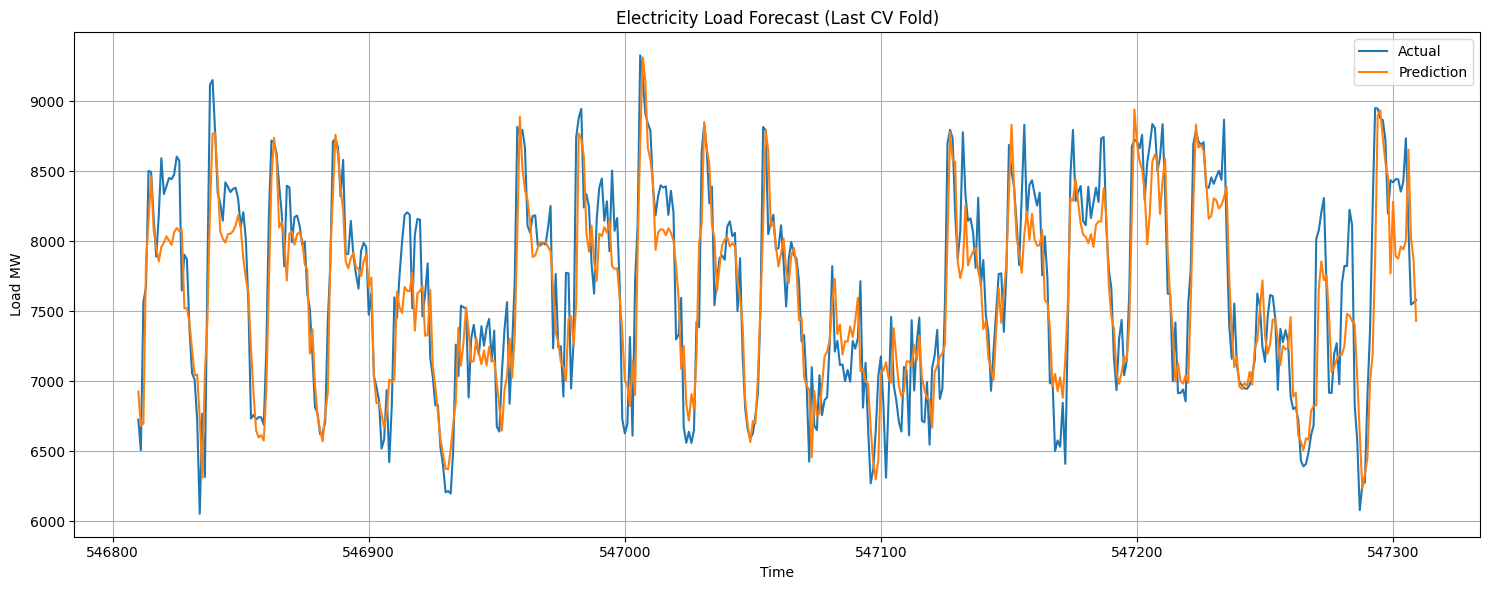

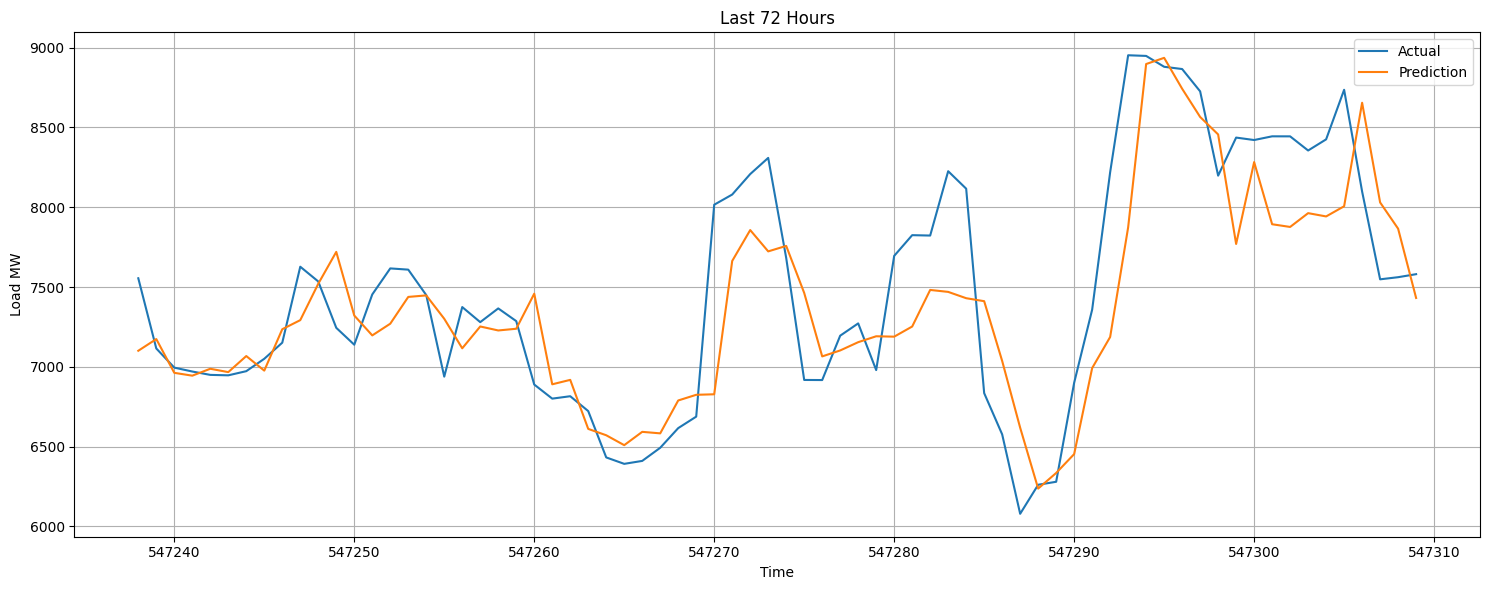

In [26]:
plot_index = y_test.index

plt.figure(figsize=(15,6))
plt.plot(plot_index, y_test.values, label="Actual")
plt.plot(plot_index, pred, label="Prediction")
plt.title("Electricity Load Forecast (Last CV Fold)")
plt.xlabel("Time")
plt.ylabel("Load MW")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ======================================================
# 7. ZOOM LAST 72 HOURS
# ======================================================

plt.figure(figsize=(15,6))
plt.plot(plot_index[-72:], y_test.values[-72:], label="Actual")
plt.plot(plot_index[-72:], pred[-72:], label="Prediction")
plt.title("Last 72 Hours")
plt.xlabel("Time")
plt.ylabel("Load MW")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
df

,timestamp_utc,city,location_id,latitude,longitude,elevation,retrieved_at_utc,temperature_2m,apparent_temperature,relative_humidity_2m,...,doy_sin,doy_cos,lag_1,lag_2,lag_24,lag_48,lag_168,y_24h,roll_mean_24,roll_std_24
0,2020-01-01 00:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,-2.3500,-5.092851,99.263000,...,0.017202,0.999852,NaN,NaN,NaN,NaN,NaN,6972.69,NaN,NaN
383117,2020-01-01 00:00:00+00:00,Lugano,7,46.010544,8.857143,282.0,2026-04-17 19:06:12.104145+00:00,6.2050,2.367880,53.312721,...,0.017202,0.999852,7012.490000,NaN,NaN,NaN,NaN,6972.69,NaN,NaN
328386,2020-01-01 00:00:00+00:00,St_Gallen,6,47.416519,9.442623,680.0,2026-04-17 19:06:12.102715+00:00,-2.2000,-5.326756,84.240669,...,0.017202,0.999852,7012.490000,7012.490000,NaN,NaN,NaN,6972.69,NaN,NaN
273655,2020-01-01 00:00:00+00:00,Lucerne,5,47.065025,8.341463,437.0,2026-04-17 19:06:12.101284+00:00,0.4085,-1.957952,99.639191,...,0.017202,0.999852,7012.490000,7012.490000,NaN,NaN,NaN,6972.69,NaN,NaN
218924,2020-01-01 00:00:00+00:00,Lausanne,4,46.572933,6.655949,500.0,2026-04-17 19:06:12.099851+00:00,-1.0030,-5.382293,85.015015,...,0.017202,0.999852,7012.490000,7012.490000,NaN,NaN,NaN,6972.69,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218923,2026-03-30 21:00:00+00:00,Basel,3,47.557117,7.549342,247.0,2026-04-17 19:06:12.098414+00:00,3.2000,-0.293931,93.152298,...,0.999209,0.039770,7580.597656,7580.597656,7548.33496,8425.173828,8219.325195,NaN,7560.608723,12.095022
164192,2026-03-30 21:00:00+00:00,Bern,2,46.924427,7.439222,554.0,2026-04-17 19:06:12.096960+00:00,1.5000,-1.164276,89.427864,...,0.999209,0.039770,7580.597656,7580.597656,7548.33496,8425.173828,8219.325195,NaN,7561.953002,12.458980
109461,2026-03-30 21:00:00+00:00,Geneva,1,46.221439,6.172249,368.0,2026-04-17 19:06:12.095267+00:00,3.1000,1.129152,91.827339,...,0.999209,0.039770,7580.597656,7580.597656,7548.33496,8425.173828,8219.325195,NaN,7563.297281,12.664576
54730,2026-03-30 21:00:00+00:00,Zurich,0,47.346218,8.543372,409.0,2026-04-17 19:06:12.092887+00:00,2.3000,-0.773526,94.787010,...,0.999209,0.039770,7580.597656,7580.597656,7548.33496,8735.749023,8952.072265,NaN,7564.641560,12.719492


Duplicate timestamps: 492579
